# Molecular Dynamics of Water Molecules

Import all necessary libraries.

In [1]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.visualize import view
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import numpy as np

Create a water molecule.

In [40]:
# write code
H2O = molecule("H2O")

Now, we want to put 27 water molecules into a cubic box. In order to do that, we need to know how much space one single water molecule occupies.
With a density of 0.9982 g/cm³ and the mass of a single water molecule, the volume of a single molecule can be calculated. From a known volume of the box, we can calculate the length of one side of the box.

Hints: the mass can be extracted from the atoms object. This needs to be converted to the correct units (Angström) using the module "units" from ase. Is the box length reasonable for a single water molecule?



In [41]:
# calculate box length for a single molecule

density = 0.9982  # denisty of water in g/cm^3 at 20°C
volume = sum(H2O.get_masses()) / (density * units.mol)    # mass/density     # make sure you covert everything to the correct units!
box_length = (volume * 1e24)**(1/3) # box length in Å for a single water molecule, calculated from the box volume

print("Box length: ", box_length)

Box length:  3.1061464666486716


View the water molecule you created.

In [42]:
# view molecule
view(H2O, viewer="x3d")

Now, we can create a cell with a single water molecule with the box length we just calculated using the function set_cell() from ase. Then we center the box around the molecule, so that it does not overlap with other molecules. Lastly, we increase the cell size such that it contains 27 molecules by multiplying the cell with a tuple that contains the factors along each side of the box (the box with one molecule is repeated X,Y,Z times in the x,y,z direction).

In [43]:
# create cell using .set_cell((box_length, box_length, box_length)) and .center(), then increase the size of the cell by a factor of 3 in each dimension to create a 3x3x3 supercell of water molecules using  *= (3, 3, 3)
H2O.set_cell((box_length, box_length, box_length))
H2O.center()
H2O *= (3, 3, 3)

In [44]:
# view the box
view(H2O, viewer="x3d")

Now, enable periodic boundary conditions.

In [45]:
# set boundary conditions
H2O.set_pbc((True, True, True))

As a calculater, we will use the TIP3P force field. To speed up the calculations, we chose a rather small cutoff radius of 4.5 Angström. This means, that no interactions larger than this distance are considered.

As the TIP3P force field does not account for internal motions, the internal degrees of freedom need to be constrained. We are applying RATTLE-type constraints, using the FixBondLength class from ase. First, we create a list containing tuples for all internal atomic distances (O-H1, O-H2, and H1-H2) for each molecule, which we will then apply on our atoms object.

In [46]:
# add a calculator TIP3P(rc=4.5)
H2O.calc = TIP3P(rc=4.5)

# add constraints to the system. Create a list containing the tuples for all internal atomic distances (O-H1, O-H2, and H1-H2) for each molecule, which we will then apply on our atoms object using the FixBondLength class from ase.
# example: water.constraints = FixBondLengths([(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]])
H2O.constraints = FixBondLengths([(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]])

First, we need to equilibrate the system. The starting structure is not very physical, so we need to simulate for a while to let the system relax and reach a more physical state. We will run an NVT simulation at 300 K for 500 fs with a time step of 5 fs. This means, that we will calculate the forces and positions of the atoms every 5 fs, and we will do this for a total of 500 fs (or 0.5 ps).


In [47]:
# define tag to save the trajectory and log filename later
tag = "water_equilibrate"
# define stepsize (in fs)
step_size = 5 * units.fs
# define number of steps
steps = 100


To start the molecular dynamics simulation, a kinetic energy needs to be assigned to every molecule, otherwise the water would start frozen at 0 K. The function MaxwellBoltzmannDistribution(atoms, temperature_K=300) gives every water atom a random "push", equivalent to the temperature set.



In [48]:
# assign starting velocities to the atoms according to a Maxwell-Boltzmann distribution at 300 K
MaxwellBoltzmannDistribution(H2O, temperature_K=300)

Then the MD engine is defined. There are two major types of MD enginges: *NVE* and *NVT*. In both cases, the number of molecules (N) and the volume (T) are constant. Additionally, either the energy (E) or temperature (T) will stay the same. In an NVE simulation, no energy can leave the system, it is completely isolated, in an NVT simulation, the absolute energy can change. To equilibrate the system, we will use an NVT simulation, as we want to keep the temperature constant.

For an NVT we will use the Langevin thermostat. It has to main purposes: adding heat by adding random noise, and removing heat by adding friction (here: 0.03). If the atoms get too hot, the thermostat removes energy from the system. If they get too cold, it adds noise to speed them up and increase the energy. Thus, in an NVT simulation, the system is "submerged" in a virtual heat bath and the temperature remains fixed. As the thermostat is constantly adding or removing energy, the total energy of the system will change.

Then, we define a trajectory file and attach it to the md enginge, such that at every time step the atom positions are saved.


In [49]:
# set up the Langevin dynamics with timestep dt in units of fs: Langevin(atoms, dt*units.fs). Include the keywords: temperature_K=300, and a friction coefficient of 0.03 (friction=0.03). Also specify the log file name using the tag defined above (logfile=f'{tag}.log').
dyn = Langevin(H2O, step_size, temperature_K=300, friction=0.03, logfile=f'{tag}.log')

# create an trajectory object called f'{tag}.traj' in mode 'w' and for the atoms object.
traj = Trajectory(f'{tag}.traj', mode="w", atoms=H2O)

# attach the trajectory object to the dynamics (dyn.attach(traj.write)). The trajectory will be written every 1 step (set keyword: interval=1).
    # .attach: A "hook" that tells the engine to run a specific command automatically.
    # traj.write: The command to save the current atom positions.
    # interval=1: Tells the computer to save the positions every single step.
dyn.attach(traj.write, interval=1)

# start the dynamics for the number of steps defined above. using atoms.run(steps)
dyn.run(steps)

In [50]:
# view the final atoms after the equlibration run
view(H2O, viewer="x3d")

Now that we have a reasonable starting structure, we can run a production simulation. We will run an NVE simulation at 300 K for 500 fs with different time steps. Thus, it makes sense to write a method that takes the time step, the number of steps in total and a tag as an argument and runs the simulation. Later, we will also perform NVT simulations with a friction of 0.03. This can all be written into one method (or two, including both MD engines). 

For an NVE we will use VelocityVerlet. In short, it knows the initial the positions and velocities of each atom and thus can calculate the forces and positions at the next timestep. Then, it moves the atoms to their new positions and repeats the process. The energy is constant, but the temperature can change during the simulation.



In [51]:
# write a function that runs the NVT simulation
def run_simulation_NVT(dt, steps, tag):
    # copy the atoms to a new variable to avoid modifying the original water structure
    water_nvt = H2O.copy()

    # attach the calculator to the new atoms variable
    water_nvt.calc = TIP3P(rc=4.5)
    
    # define the md enginge with the properties: atoms, timestep in fs, logfile to save output. Use the Langevin as above
    dyn = Langevin(water_nvt, dt, temperature_K=300, friction=0.03, logfile=f'{tag}.log')

    # create a trajectory object to save the positions of the atoms at each time step
    # attach it to the dynamics, and set it to write every 1 step (interval=1)
    traj = Trajectory(f'{tag}.traj', mode="w", atoms=water_nvt)
    dyn.attach(traj.write, interval=1)

    # print a message to indicate the simulation is starting
    print("Starting simulation...")
    # start the simulation
    dyn.run(steps)

In [52]:
# write a function that runs the NVE simulation
def run_simulation_NVE(dt, steps, tag):
    # copy the atoms to a new variable to avoid modifying the original water structure
    water_nve = H2O.copy()

    # attach the calculator to the new atoms variable
    water_nve.calc = TIP3P(rc=4.5)

    # define the md enginge with the properties: atoms, timestep in fs, logfile to save output. Use the VelocityVerlet
    dyn = VelocityVerlet(water_nve, dt, logfile=f'{tag}.log')
    
    # create a trajectory object to save the positions of the atoms at each time step
    # attach it to the dynamics, and set it to write every 1 step (interval=1)
    traj = Trajectory(f'{tag}.traj', mode="w", atoms=water_nve)
    dyn.attach(traj.write, interval=1)

    # print a message to indicate the simulation is starting
    print("Starting simulation...")
    # start the simulation
    dyn.run(steps)


Define the timestep size, the number of timesteps and the logfile to save the output. Then, perform simulations with an NVE for timesteps of 2, 5 and 15 fs. The total simulation time should be 0.5 ps each time.
Start with the structures after the equilibration run each time, so that the trajectories are comparable.

In [56]:
# perform NVE simulations for different time steps. Set number of timesteps such that it simulated 0.5 ps each time. Include the length of the timesteps in the tag for the log and trajectory files.
for time_step in [2, 5, 15]:
    steps = 500//time_step
    run_simulation_NVE(time_step * units.fs, steps, f"water_NVE_{time_step}fs")

Starting simulation...


RuntimeError: Did not converge

Lastly, run the simulation with timesteps of 2 fs and the Langevin thermostat. Start with the structures after the equilibration run, not after the NVE runs.

In [57]:
# run the NVT simulation 
run_simulation_NVT(2 * units.fs, 250, "water_NVT_2fs")

Starting simulation...


Plot the energy and temperature vs time for all simulation runs.

In [75]:
# create arrays to store the time, total energy, potential energy, kinetic energy, and temperature from the log file of the simulations using np.loadtxt. Skip the first row of the log file and unpack the columns into separate arrays.
# The arrays could be called: time, etot, epot, ekin, temp (then the plotting function will work without modification)
time, etot, epot, ekin, temp = np.loadtxt(
    'water_NVT_2fs.log', 
    skiprows=1, 
    unpack=True
)

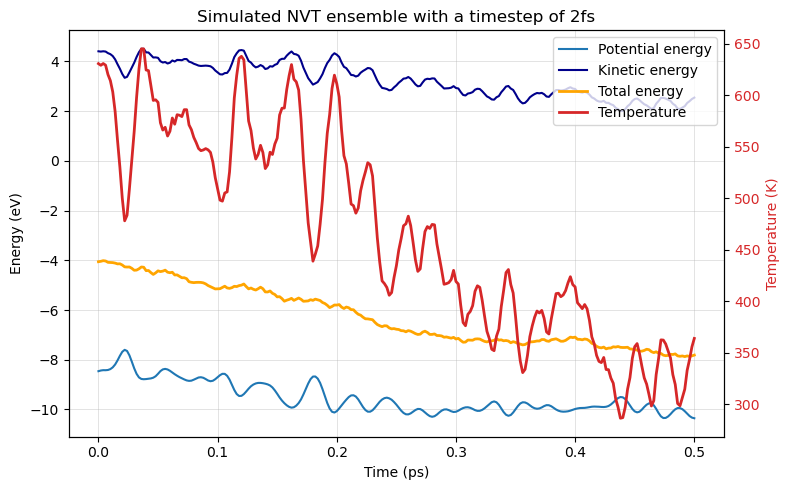

In [76]:
# plot the energy and temperature over time:

# Create the figure and the first axis (Energy)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Energies on the left axis
ax1.plot(time, epot, label='Potential energy', color='tab:blue')
ax1.plot(time, ekin, label='Kinetic energy', color='darkblue')
ax1.plot(time, etot, label='Total energy', color='orange', linewidth=2)

ax1.set_xlabel('Time (ps)')
ax1.set_ylabel('Energy (eV)')
# ax1.set_ylim(-9.5, -7.3)      # you can change the range of the y-axis to better visualize the energy fluctuations
ax1.grid(True, linewidth=0.5, alpha=0.5)
ax1.set_title("Simulated NVT ensemble with a timestep of 2fs")

# Create a twin axis for Temperature
ax2 = ax1.twinx() 

# Plot Temperature on the right axis
ax2.plot(time, temp, label='Temperature', color='tab:red', linewidth=2)

ax2.set_ylabel('Temperature (K)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Handling the legends
# Because we have two different axes, we need to combine the labels manually
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()